Saving intel_image_dataset1.zip to intel_image_dataset1 (2).zip
 Dataset extracted!
Found 14034 files belonging to 6 classes.
Found 3000 files belonging to 6 classes.
 Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Epoch 1/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 17s 32ms/step - accuracy: 0.5767 - loss: 1.0367 - val_accuracy: 0.6620 - val_loss: 0.8901
Epoch 2/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - accuracy: 0.7364 - loss: 0.7000 - val_accuracy: 0.7750 - val_loss: 0.6097
Epoch 3/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - accuracy: 0.7906 - loss: 0.5667 - val_accuracy: 0.7780 - val_loss: 0.5912
Epoch 4/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - accuracy: 0.8268 - loss: 0.4779 - val_accuracy: 0.8143 - val_loss: 0.5208
Epoch 5/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - accuracy: 0.8462 - loss: 0.4160 - val_accuracy: 0.7773 - val_loss: 0.6423
Epoch 6/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.8735 - loss: 0.3517 - val_accuracy: 0.817

 Test Accuracy: 0.8116666674613953
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step
18033.jpg → This image is: buildings (0.98)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
6885.jpg → This image is: sea (0.99)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
13541.jpg → This image is: forest (1.00)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
515.jpg → This image is: street (0.98)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
17859.jpg → This image is: sea (0.98)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
9855.jpg → This image is: glacier (1.00)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
15980.jpg → This image is: forest (1.00)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
20716.jpg → This image is: forest (0.94)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
7395.jpg → This image is: sea (1.00)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
2801.jpg → This image is: glacier (1.00)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
8873.jpg → This image is: street (0.99)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
11147.jpg → This image is: street (0.97)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s

ValueError: num must be an integer with 1 <= num <= 12, not 13

/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)


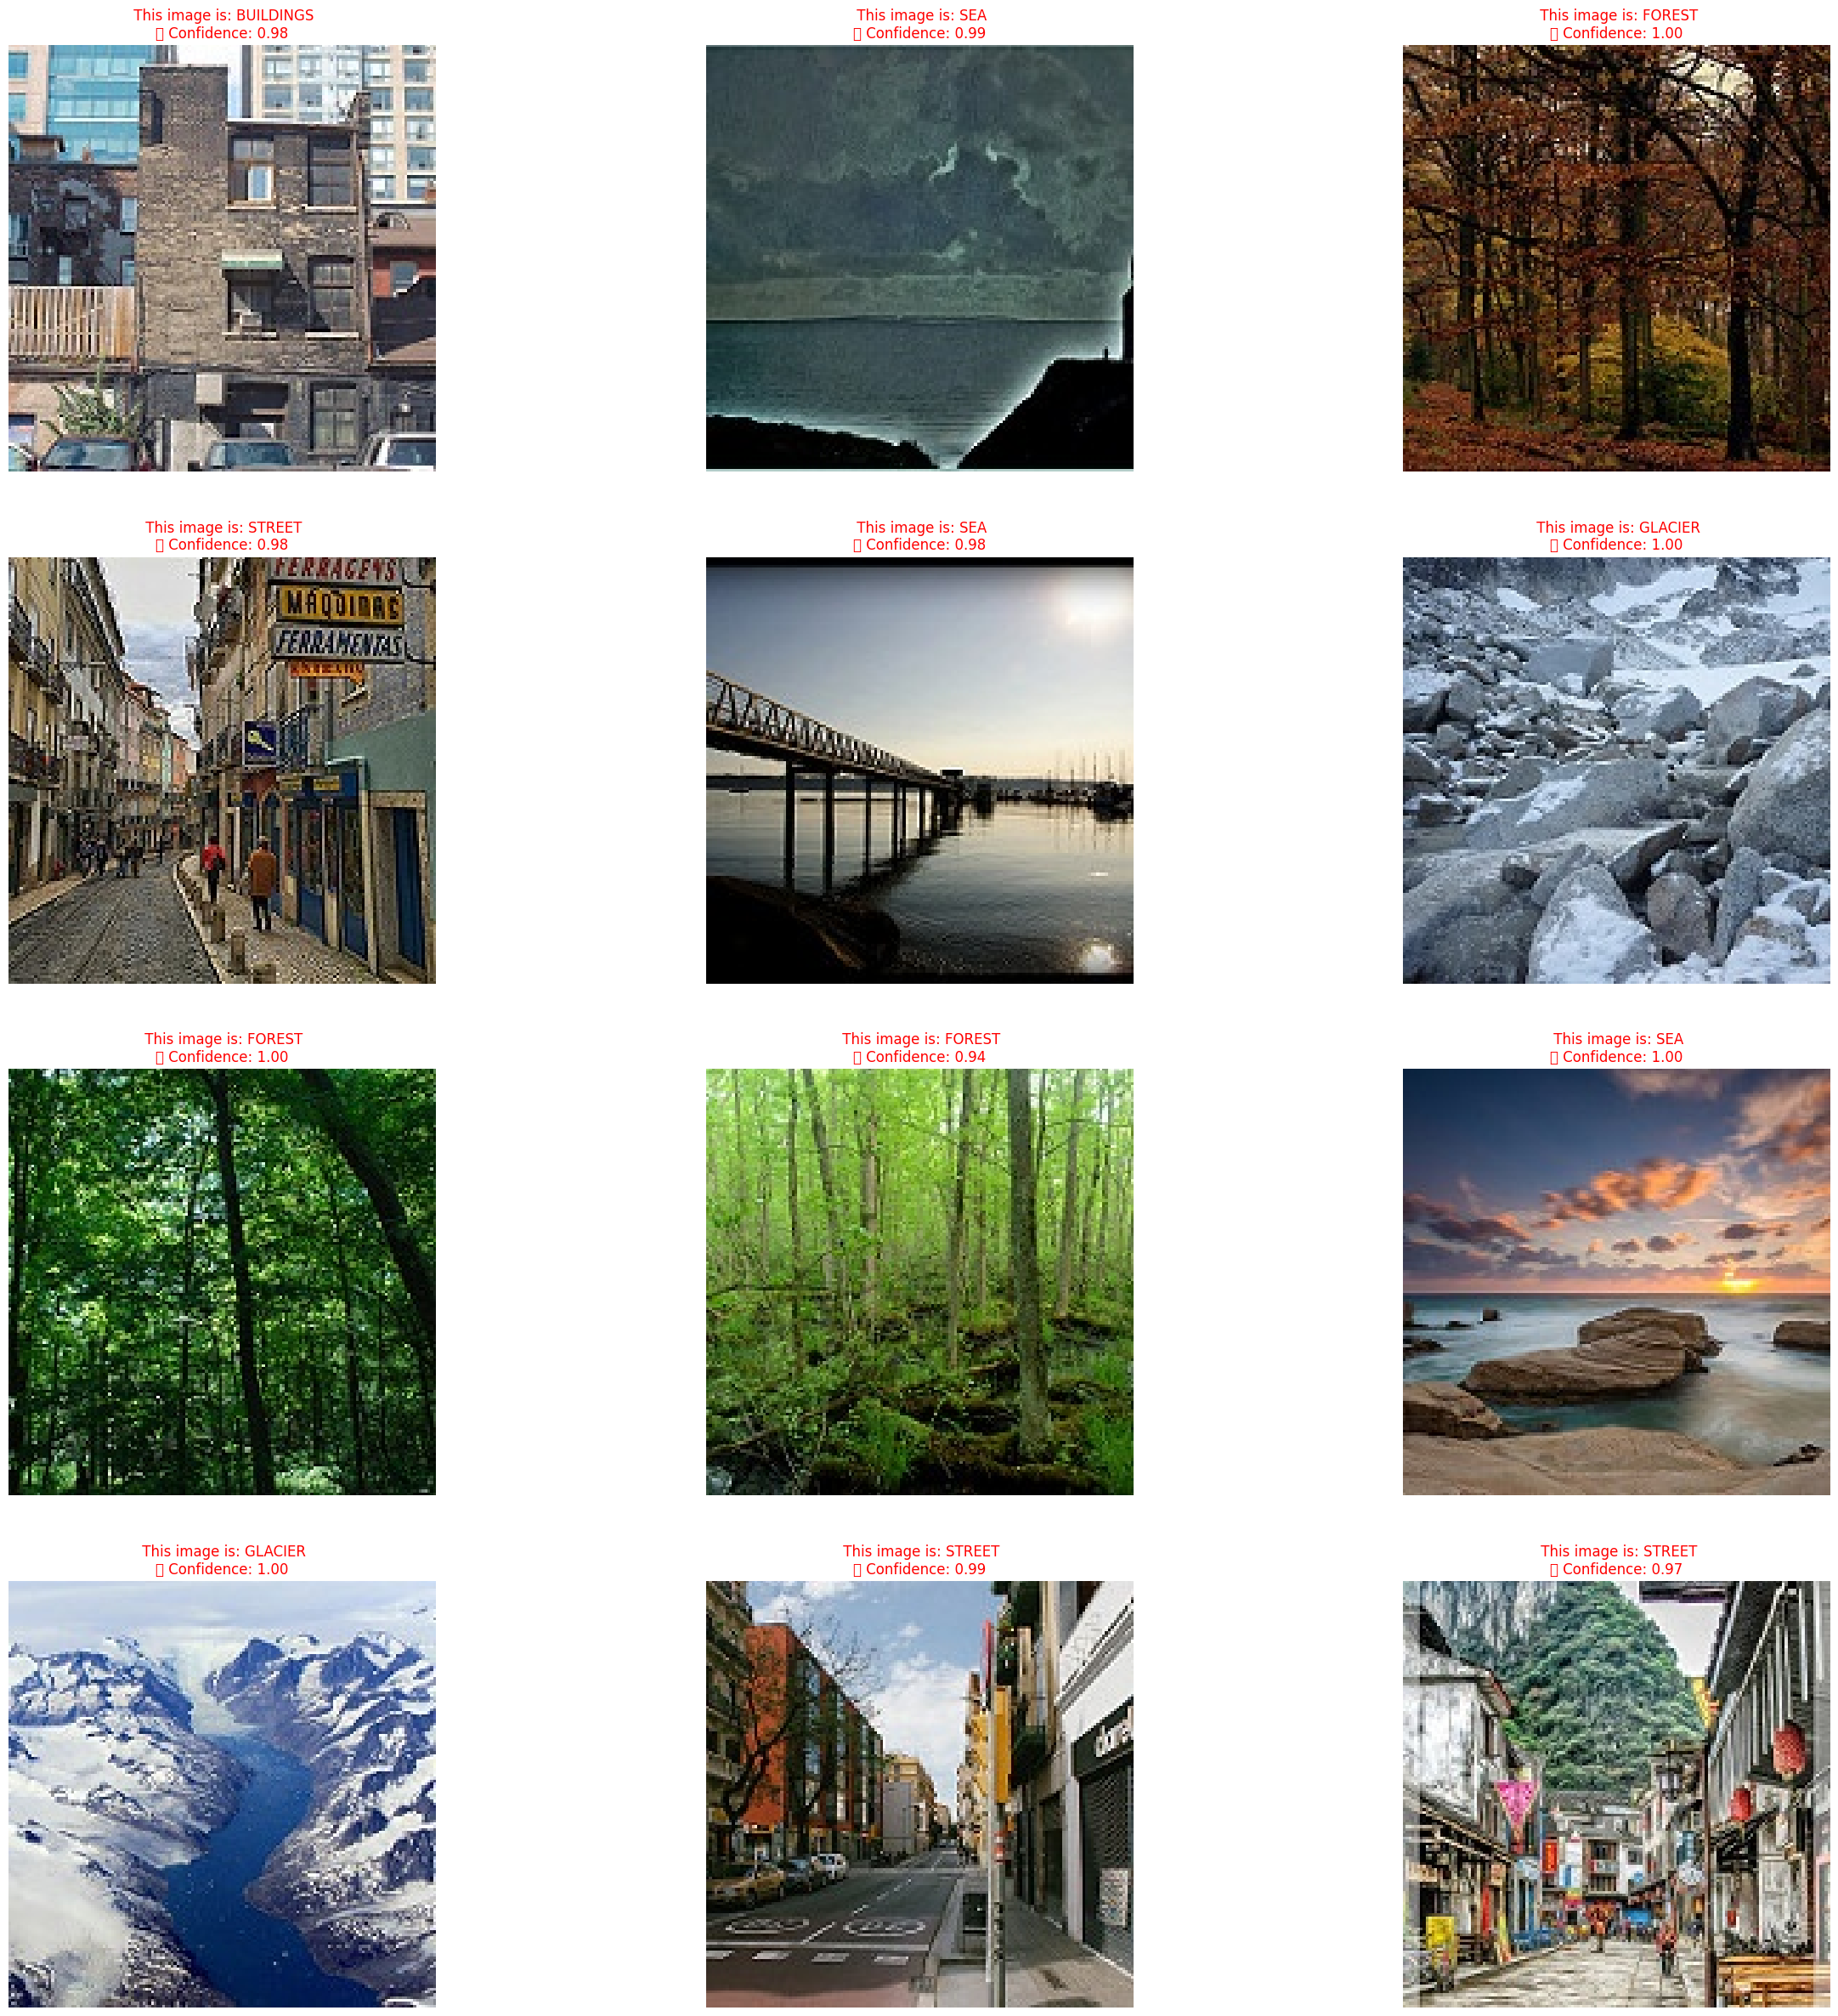

In [7]:

from google.colab import files
uploaded = files.upload()

import zipfile, os

zip_name = list(uploaded.keys())[0]
with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall()

print(" Dataset extracted!")

train_dir = "intel_image_dataset1/seg_train"
test_dir = "intel_image_dataset1/seg_test"
pred_dir = "intel_image_dataset1/seg_pred"


import tensorflow as tf

train_data = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(150,150),
    batch_size=32
)

test_data = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(150,150),
    batch_size=32
)

class_names = train_data.class_names
print(" Classes:", class_names)


train_data = train_data.map(lambda x, y: (x/255.0, y))
test_data = test_data.map(lambda x, y: (x/255.0, y))

from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(len(class_names), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


history = model.fit(
    train_data,
    epochs=10,
    validation_data=test_data
)

loss, acc = model.evaluate(test_data)
print(" Test Accuracy:", acc)


model.save("cnn_intel_model.h5")


import numpy as np
from tensorflow.keras.preprocessing import image

def predict_image(img_path):
    img = image.load_img(img_path, target_size=(150,150))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    class_index = np.argmax(prediction)
    confidence = np.max(prediction)

    label = class_names[class_index]

    return label, confidence, img


import matplotlib.pyplot as plt


pred_path = pred_dir
image_files = [f for f in os.listdir(pred_path) if f.endswith(('.jpg','.png','.jpeg'))]


image_files = image_files[:30]

plt.figure(figsize=(30,30))

for i, img_name in enumerate(image_files):
    img_path = os.path.join(pred_path, img_name)

    pred_class, confidence, img = predict_image(img_path)


    true_class = img_name.split('_')[0]

    color = "green" if pred_class == true_class else "red"

    plt.subplot(4,3,i+1)
    plt.imshow(img)
    plt.axis("off")


    plt.title(
        f" This image is: {pred_class.upper()}\n📊 Confidence: {confidence:.2f}",
        color=color,
        fontsize=12
    )

    print(f"{img_name} → This image is: {pred_class} ({confidence:.2f})")

plt.tight_layout()
plt.show()